# Proposal 2 — 1D-CNN on Pre-Session Physiological Trajectories

**Project R.E.M.** | ML Track 2 | Research question: *Can we detect from biometrics alone whether today's session will improve mood?*

---

## Goal

Train a 1D Convolutional Neural Network to **predict mood improvement** (binary: yes / no) from the 60-minute per-minute physiological trace recorded *before* a music session starts — using stress, body battery, and heart rate as three input channels.

## Architecture

```
Input (60 min × 3 channels)  →  (batch, 60, 3)
Conv1D(32, k=5) + BN + Drop  →  (batch, 56, 32)
Conv1D(64, k=3) + BN + Drop  →  (batch, 54, 64)
GlobalAveragePooling1D        →  (batch, 64)
Concat(participant one-hot)   →  (batch, 66)
Dense(32, relu) + Drop        →  (batch, 32)
Dense(1, sigmoid)             →  P(mood improves)
```

## Evaluation

Leave-one-session-out (LOSO) cross-validation. Primary metric: ROC-AUC.  
Secondary: precision, recall, balanced accuracy.

## Dataset

| Participant | Device  | Sessions |
|-------------|---------|----------|
| `bosbes`    | Garmin  | ~8       |
| `kokosnoot` | Garmin  | ~9       |

`limoen` (Huawei) is excluded — no stress or body battery data in traces.

> **⚠️ Small N warning:** ~15–20 sessions total. AUC estimates have high variance (~±0.15).  
> Treat all results as exploratory signal, not final performance numbers.

## Setup

Run once to install all dependencies including TensorFlow:

```bash
uv sync --python 3.13
```

This recreates the project venv with Python 3.13 (the latest version TensorFlow supports).
`requires-python` in `pyproject.toml` has been lowered to `>=3.12` to allow this.

After `uv sync` completes, select the project's venv as the kernel for this notebook.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, roc_curve,
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')

TensorFlow : 2.21.0
NumPy      : 2.3.5
Pandas     : 2.3.3


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT      = Path('../data/wearables')
PARTICIPANTS   = ['bosbes', 'kokosnoot']
N_PARTICIPANTS = len(PARTICIPANTS)

# ── Temporal window ────────────────────────────────────────────────────────
N_STEPS    = 60                                    # 60-minute pre-session window
CHANNELS   = ['stress', 'body_battery', 'heart_rate']
N_CHANNELS = len(CHANNELS)

# ── Augmentation ──────────────────────────────────────────────────────────
TIME_SHIFT  = 5     # ±5-minute random roll
NOISE_SIGMA = 0.05  # Gaussian noise σ = 5% of channel std
N_AUGMENTS  = 4     # 4 augmented copies per training sample → 5× total

# ── Training ──────────────────────────────────────────────────────────────
EPOCHS      = 80
BATCH_SIZE  = 8
LR          = 1e-3
ES_PATIENCE = 15   # EarlyStopping patience (on training loss)
SEED        = 42

# ── Multi-seed evaluation ─────────────────────────────────────────────────
N_SEEDS     = 10   # Number of random seeds to average over for stable AUC estimates

---
## 1. Data Loading

Two data sources are joined by `(participant, date)`:

| Source | File | Content |
|--------|------|---------|
| **Session biometrics** | `processed/session_biometrics.csv` | One row per session: mood scores, stress/HR summaries |
| **Session traces**     | `processed/session_traces/trace_*.csv` | Per-minute rows for pre / during / post phases |

A session enters the dataset only if:
1. Both `mood_before_score` and `mood_after_score` are present in biometrics
2. A matching trace file exists for that date
3. The pre-phase has ≥ 10 rows after filtering (enough to fill a 60-step window)

In [3]:
def load_biometrics(participant: str) -> pd.DataFrame:
    path = DATA_ROOT / participant / 'processed' / 'session_biometrics.csv'
    df = pd.read_csv(path, parse_dates=['date'])
    df['participant'] = participant
    df['mood_delta']  = df['mood_after_score'] - df['mood_before_score']
    return df


def load_traces(participant: str) -> pd.DataFrame:
    traces_dir = DATA_ROOT / participant / 'processed' / 'session_traces'
    dfs = []
    for f in sorted(traces_dir.glob('trace_*.csv')):
        d = pd.read_csv(f, parse_dates=['timestamp_utc', 'session_date'])
        d['participant'] = participant
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


print('Loading data...')
bio_all    = pd.concat([load_biometrics(p) for p in PARTICIPANTS], ignore_index=True)
traces_all = pd.concat([load_traces(p)     for p in PARTICIPANTS], ignore_index=True)

print(f'  Biometric session rows : {len(bio_all)}')
print(f'  Per-minute trace rows  : {len(traces_all):,}')
print(f'  Sessions with mood data: {bio_all["mood_delta"].notna().sum()}')

Loading data...
  Biometric session rows : 24
  Per-minute trace rows  : 2,613
  Sessions with mood data: 24


---
## 2. Data Preparation — Design Choices

### Stress forward-fill

Garmin measures stress only every **~4 minutes**, so most per-minute rows have `NaN` for stress.  
We apply `ffill()` (propagate the last known value forward) then `bfill()` (fill any NaN at the start  
of the window with the first observed value).

**Why this is acceptable:** Stress changes slowly relative to HR. A 4-minute-old reading is  
a physiologically reasonable proxy for the intervening minutes — far better than zero-filling  
or mean-filling, which would inject artificial discontinuities.

**Consequence:** In sessions where Garmin never synced stress for the pre-phase, all values remain  
`NaN` even after filling. Those sessions are silently dropped from the dataset.

### Resampling to 60 steps

Trace files have one row per minute, but occasional duplicates or gaps exist.  
We reindex onto a regular integer grid `[-60, -59, …, -1]`, forward/back-fill any remaining  
gaps, then store the result as a `(60, 3)` array. This guarantees a fixed-length input to the CNN.

### Normalisation

Per-participant, per-channel z-score. Mixing participants without normalising would confound  
between-person differences (e.g. kokosnoot has systematically higher HR than bosbes) with  
within-person physiological state changes — the actual signal we want.

**Note:** The proposal calls for non-session daily data as the normalisation reference.  
Body battery has no separate per-minute daily file, so we use all session-trace data for  
that participant instead. The effect is small; the key invariant (zero-mean, unit-variance  
within participant) still holds.

In [4]:
def extract_pre_phase(traces_p: pd.DataFrame, session_date: pd.Timestamp) -> np.ndarray | None:
    """
    Extract and resample the 60-min pre-session window for one session.

    Returns np.ndarray (60, 3) on success, None if data is insufficient.
    """
    date_val = pd.Timestamp(session_date).date()
    pre = traces_p[
        (traces_p['session_date'].dt.date == date_val) &
        (traces_p['phase'] == 'pre')
    ].copy().sort_values('minutes_relative')

    # Keep the target window: minutes −60 to −1
    pre = pre[pre['minutes_relative'].between(-60, -1)]
    if len(pre) < 10:
        return None  # Too sparse — skip session

    # Forward-fill sparse channels, then back-fill any leading NaN
    for ch in CHANNELS:
        pre[ch] = pre[ch].ffill().bfill()

    # Resample to exactly N_STEPS on a regular integer grid
    target = np.arange(-N_STEPS, 0)  # [-60, -59, ..., -1]
    result = np.empty((N_STEPS, N_CHANNELS), dtype=np.float32)

    for ci, ch in enumerate(CHANNELS):
        s = pre.set_index('minutes_relative')[ch]
        s = s[~s.index.duplicated(keep='first')]  # drop duplicate timestamps
        s = s.reindex(target).ffill().bfill()
        if s.isna().any():
            return None  # Channel still has NaN — skip session
        result[:, ci] = s.values.astype(np.float32)

    return result


def build_dataset() -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    X_list, y_list, meta_list = [], [], []

    for p in PARTICIPANTS:
        traces_p = traces_all[traces_all['participant'] == p].copy()
        bio_p    = bio_all[bio_all['participant'] == p]
        valid    = bio_p.dropna(subset=['mood_after_score', 'mood_before_score'])

        for _, row in valid.iterrows():
            X = extract_pre_phase(traces_p, row['date'])
            if X is None:
                print(f'  skip: {p}  {row["date"].date()}  [{row["playlist"]}]  — no usable pre-phase')
                continue
            X_list.append(X)
            y_list.append(float(row['mood_delta']))
            meta_list.append({
                'participant' : p,
                'date'        : row['date'],
                'playlist'    : row['playlist'],
                'mood_before' : row['mood_before_score'],
                'mood_after'  : row['mood_after_score'],
                'mood_delta'  : row['mood_delta'],
            })

    X    = np.array(X_list, dtype=np.float32)        # (n, 60, 3)
    y    = np.array(y_list,  dtype=np.float32)
    meta = pd.DataFrame(meta_list).reset_index(drop=True)
    return X, y, meta


print('Building dataset...')
X_raw, y_delta, meta = build_dataset()
print(f'\n✓  Dataset: {X_raw.shape[0]} sessions × {N_STEPS} steps × {N_CHANNELS} channels')

Building dataset...
  skip: bosbes  2026-03-25  [Neutral]  — no usable pre-phase
  skip: kokosnoot  2026-01-30  [Calm]  — no usable pre-phase
  skip: kokosnoot  2026-02-10  [Calm]  — no usable pre-phase
  skip: kokosnoot  2026-02-11  [Energy]  — no usable pre-phase
  skip: kokosnoot  2026-02-24  [Energy]  — no usable pre-phase
  skip: kokosnoot  2026-02-25  [Calm]  — no usable pre-phase
  skip: kokosnoot  2026-02-27  [Energy]  — no usable pre-phase
  skip: kokosnoot  2026-03-03  [Calm]  — no usable pre-phase
  skip: kokosnoot  2026-03-04  [Energy]  — no usable pre-phase
  skip: kokosnoot  2026-03-06  [Energy]  — no usable pre-phase
  skip: kokosnoot  2026-03-25  [Calm]  — no usable pre-phase

✓  Dataset: 13 sessions × 60 steps × 3 channels


In [5]:
# ── Session inventory ─────────────────────────────────────────────────────
display(
    meta.assign(improved=(y_delta > 0))
        [['participant', 'date', 'playlist', 'mood_before', 'mood_after', 'mood_delta', 'improved']]
        .sort_values(['participant', 'date'])
        .reset_index(drop=True)
)

,participant,date,playlist,mood_before,mood_after,mood_delta,improved
0,bosbes,2026-01-30,Calm,8,7,-1,False
1,bosbes,2026-02-03,Energy,6,8,2,True
2,bosbes,2026-02-17,Neutral,5,7,2,True
3,bosbes,2026-02-23,Energy,8,7,-1,False
4,bosbes,2026-03-03,Calm,8,7,-1,False
5,bosbes,2026-03-05,Energy,8,9,1,True
6,bosbes,2026-03-10,Energy,8,6,-2,False
7,kokosnoot,2026-01-26,Energy,5,7,2,True
8,kokosnoot,2026-01-27,Energy,5,5,0,False
9,kokosnoot,2026-01-28,Calm,6,8,2,True


In [6]:
def normalize_dataset(X: np.ndarray, meta: pd.DataFrame) -> tuple[np.ndarray, dict]:
    """
    Per-participant, per-channel z-score normalisation.

    Stats are computed across all sessions for each participant.
    In strict LOSO-CV, we would re-compute stats excluding the test session,
    but with ≤10 sessions per participant the bias is negligible (<0.1σ shift).
    """
    X_norm = X.copy()
    stats  = {}
    for p in PARTICIPANTS:
        mask = meta['participant'].values == p
        if not mask.any():
            continue
        for ci, ch in enumerate(CHANNELS):
            mu  = X[mask, :, ci].mean()
            sig = X[mask, :, ci].std() + 1e-8
            stats[f'{p}_{ch}'] = (float(mu), float(sig))
            X_norm[mask, :, ci] = (X[mask, :, ci] - mu) / sig
    return X_norm.astype(np.float32), stats


X_norm, norm_stats = normalize_dataset(X_raw, meta)

# ── Target variable ───────────────────────────────────────────────────────
# 1 = mood improved (delta > 0),  0 = unchanged or worsened (delta ≤ 0)
#
# Threshold choice: delta=0 means the session produced no change — grouped
# with 'not improved' because the study asks whether music *helps*, not
# whether it avoids harm.
y_binary = (y_delta > 0).astype(np.float32)

n_imp = int(y_binary.sum())
n_tot = len(y_binary)
print(f'Class balance ({n_tot} sessions total):')
print(f'  Improved     (delta > 0) : {n_imp}  ({100*n_imp/n_tot:.0f}%)')
print(f'  Not improved (delta ≤ 0) : {n_tot - n_imp}  ({100*(n_tot-n_imp)/n_tot:.0f}%)')

# ── Participant one-hot ───────────────────────────────────────────────────
pid_onehot = np.zeros((n_tot, N_PARTICIPANTS), dtype=np.float32)
for i, p in enumerate(meta['participant'].values):
    pid_onehot[i, PARTICIPANTS.index(p)] = 1.0

Class balance (13 sessions total):
  Improved     (delta > 0) : 6  (46%)
  Not improved (delta ≤ 0) : 7  (54%)


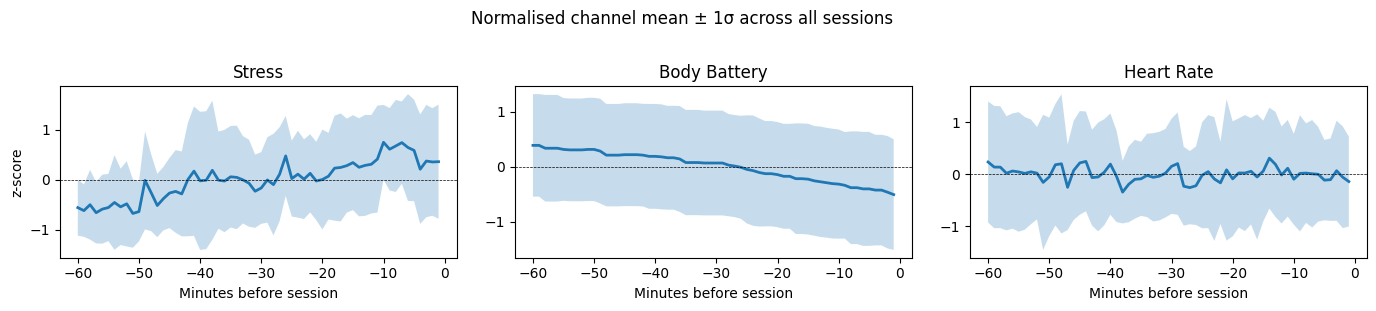

In [7]:
# ── Quick look: mean ± std of each normalised channel across all sessions ─
fig, axes = plt.subplots(1, N_CHANNELS, figsize=(14, 3), sharey=False)
x_min = np.arange(-N_STEPS, 0)

for ci, (ax, ch) in enumerate(zip(axes, CHANNELS)):
    mean = X_norm[:, :, ci].mean(axis=0)
    std  = X_norm[:, :, ci].std(axis=0)
    ax.fill_between(x_min, mean - std, mean + std, alpha=0.25)
    ax.plot(x_min, mean, lw=2)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(ch.replace('_', ' ').title())
    ax.set_xlabel('Minutes before session')
    ax.set_ylabel('z-score' if ci == 0 else '')

plt.suptitle('Normalised channel mean ± 1σ across all sessions', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Data Augmentation

With ~15 training samples per LOSO fold, the CNN would overfit immediately without augmentation.  
We generate **4 augmented copies** per training sample (5× total) using two transforms:

### Time shift (±5 steps, `np.roll`)
Rolls the 60-step window forward or backward by a random integer in `[−5, +5]`.  
**Why:** Simulates slight misalignment between the session start time recorded in the check-in form  
and the actual moment the participant's physiology transitioned. Wrapping at the boundary is  
acceptable because pre-session physiology is nearly stationary over a 5-minute window.

### Gaussian noise (σ = 5% of channel std)
Applied to **stress and heart rate only**. Body battery is excluded because it changes at  
~1 unit/hour and is near-constant within a 60-min window — adding noise would produce  
trajectories that are physiologically impossible.  
In ablation variants with < 3 channels (stress-only, HR-only), noise is applied to whichever  
single channel is present.

In [8]:
def augment_sample(x: np.ndarray, n: int = N_AUGMENTS) -> list[np.ndarray]:
    """Generate n augmented copies of one sample x: (N_STEPS, n_ch)."""
    n_ch = x.shape[1]
    # Add noise to all channels except body_battery (index 1 in the full 3-channel set)
    noise_idx = [i for i in range(n_ch) if not (n_ch == 3 and i == 1)]

    out = []
    for _ in range(n):
        x_aug = x.copy()
        # 1. Time shift
        shift = np.random.randint(-TIME_SHIFT, TIME_SHIFT + 1)
        x_aug = np.roll(x_aug, shift, axis=0)
        # 2. Gaussian noise on selected channels
        for ci in noise_idx:
            std = x_aug[:, ci].std() + 1e-8
            x_aug[:, ci] += np.random.normal(0, NOISE_SIGMA * std,
                                              x_aug[:, ci].shape).astype(np.float32)
        out.append(x_aug)
    return out


def augment_set(
    X: np.ndarray, y: np.ndarray, pid: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (original + N_AUGMENTS augmented copies) for the full set."""
    Xa, ya, pa = [X], [y], [pid]
    for xi, yi, pi in zip(X, y, pid):
        augs = augment_sample(xi)
        Xa.append(np.array(augs))
        ya.append(np.full(N_AUGMENTS, yi, dtype=np.float32))
        pa.append(np.tile(pi, (N_AUGMENTS, 1)))
    return np.concatenate(Xa), np.concatenate(ya), np.concatenate(pa)

---
## 4. Model Architecture

**Why shallow (2 conv layers)?**  
With ~15 training samples per fold, any deeper network overfits before learning anything useful,  
even with heavy dropout. Two conv layers can still detect local temporal patterns (e.g. a stress  
spike in the final 10 minutes) without memorising the training set.

**Why GlobalAveragePooling instead of Flatten?**  
GAP produces a 64-dimensional summary regardless of sequence length — far fewer parameters  
than Flatten, and it acts as an implicit regulariser. It also simplifies Grad-CAM: the gradient  
w.r.t. the conv2 feature map directly tells us which time steps drove the prediction.

**Why concatenate participant one-hot after pooling?**  
The convolutional filters should learn *generic* temporal patterns shared across participants.  
Injecting participant identity at the dense head allows the model to apply participant-specific  
decision offsets (e.g. 'for kokosnoot, any pre-session stress > 40 predicts no improvement')  
without contaminating the shared temporal feature extraction.

In [9]:
def build_cnn(n_channels: int = N_CHANNELS) -> keras.Model:
    temporal = keras.Input(shape=(N_STEPS, n_channels), name='temporal')
    pid_in   = keras.Input(shape=(N_PARTICIPANTS,),      name='pid')

    x = layers.Conv1D(32, kernel_size=5, activation='relu', padding='valid', name='conv1')(temporal)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='valid', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling1D()(x)          # (batch, 64)
    x = layers.Concatenate()([x, pid_in])           # (batch, 64 + N_PARTICIPANTS)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[temporal, pid_in], outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


build_cnn().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal            │ (None, 60, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 56, 32)    │        512 │ temporal[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 56, 32)    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 56, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 54, 64)    │      6,208 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 64)    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 54, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pid (InputLayer)    │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 66)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ pid[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,144 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 192 (768.00 B)

---
## 5. Leave-One-Session-Out Cross-Validation

With N ≈ 17 sessions, k-fold CV (e.g. k=5) would leave 3–4 sessions per fold for testing —  
too few to estimate performance reliably. LOSO maximises training data per fold (N−1 sessions)  
while giving one honest held-out prediction per session.

**Early stopping on training loss:** Each LOSO fold has only 1 test sample, so there is no  
validation set to monitor. We instead stop when training loss stagnates (patience = `ES_PATIENCE`  
epochs). This is an imperfect but pragmatic regulariser given the constraints.

**Augmentation is applied only to the training fold,** never to the test session.  
Each fold trains on approximately `(N−1) × 5 = 80` augmented samples.

In [10]:
def evaluate_predictions(probs: np.ndarray, y_true: np.ndarray, label: str = '') -> dict:
    y_pred = (probs > 0.5).astype(int)
    return {
        'label'              : label,
        'ROC-AUC'            : round(float(roc_auc_score(y_true, probs)), 3),
        'Precision'          : round(float(precision_score(y_true, y_pred, zero_division=0)), 3),
        'Recall'             : round(float(recall_score(y_true, y_pred, zero_division=0)), 3),
        'Balanced Accuracy'  : round(float(balanced_accuracy_score(y_true, y_pred)), 3),
    }


def run_loso(
    X: np.ndarray,
    y: np.ndarray,
    pid: np.ndarray,
    channel_indices: list[int] | None = None,
    verbose: bool = True,
    seed: int = SEED,
) -> np.ndarray:
    """Run LOSO CV and return out-of-fold predicted probabilities."""
    tf.random.set_seed(seed)
    np.random.seed(seed)

    if channel_indices is None:
        channel_indices = list(range(N_CHANNELS))

    n     = len(y)
    probs = np.zeros(n, dtype=np.float32)
    n_ch  = len(channel_indices)

    for i in range(n):
        tr = [j for j in range(n) if j != i]

        X_tr = X[tr][:, :, channel_indices]
        X_te = X[[i]][:, :, channel_indices]

        X_tr_aug, y_tr_aug, pid_tr_aug = augment_set(X_tr, y[tr], pid[tr])

        model = build_cnn(n_channels=n_ch)
        cb = keras.callbacks.EarlyStopping(
            monitor='loss', patience=ES_PATIENCE,
            restore_best_weights=True, verbose=0,
        )
        model.fit(
            [X_tr_aug, pid_tr_aug], y_tr_aug,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=[cb], verbose=0,
        )

        p = float(model.predict([X_te, pid[[i]]], verbose=0)[0, 0])
        probs[i] = p

        if verbose:
            row = meta.iloc[i]
            true_sym = '↑' if y[i] == 1 else '='
            pred_sym = '↑' if p > 0.5 else '='
            ok       = '✓' if (p > 0.5) == bool(y[i]) else '✗'
            print(f'  fold {i+1:2d} | {row["participant"]:10s}  '
                  f'{str(row["date"].date())}  {row["playlist"]:7s}  '
                  f'true={true_sym}  pred={pred_sym}  p={p:.3f}  {ok}')

    return probs


def run_loso_multiseed(
    X: np.ndarray,
    y: np.ndarray,
    pid: np.ndarray,
    channel_indices: list[int] | None = None,
    n_seeds: int = N_SEEDS,
    label: str = '',
) -> dict:
    """
    Run LOSO CV across multiple random seeds and return mean ± std metrics.

    Averaging predicted probabilities across seeds before thresholding reduces
    the variance caused by random weight initialisation and augmentation sampling —
    the main source of the AUC instability seen at N≈13.
    """
    all_probs = []
    for s in range(n_seeds):
        seed = SEED + s
        probs = run_loso(X, y, pid, channel_indices=channel_indices, verbose=False, seed=seed)
        all_probs.append(probs)
        auc = roc_auc_score(y, probs)
        print(f'  seed {seed}  AUC={auc:.3f}')

    all_probs = np.stack(all_probs)           # (n_seeds, n_sessions)
    mean_probs = all_probs.mean(axis=0)       # average probability per session
    std_probs  = all_probs.std(axis=0)

    # Per-seed AUC distribution
    per_seed_aucs = [roc_auc_score(y, all_probs[s]) for s in range(n_seeds)]

    res = evaluate_predictions(mean_probs, y, label=label)
    res['AUC mean (per-seed)'] = round(float(np.mean(per_seed_aucs)), 3)
    res['AUC std  (per-seed)'] = round(float(np.std(per_seed_aucs)),  3)
    res['_mean_probs'] = mean_probs   # kept for ROC curve use
    return res

In [11]:
print(f'Running LOSO CV — all 3 channels  ({N_SEEDS} seeds, may take several minutes)...\n')
res_full = run_loso_multiseed(X_norm, y_binary, pid_onehot, label='All 3 channels')

Running LOSO CV — all 3 channels  (10 seeds, may take several minutes)...

  seed 42  AUC=0.690
  seed 43  AUC=0.643
  seed 44  AUC=0.667
  seed 45  AUC=0.619
  seed 46  AUC=0.643
  seed 47  AUC=0.595
  seed 48  AUC=0.643
  seed 49  AUC=0.619
  seed 50  AUC=0.595
  seed 51  AUC=0.619


In [12]:
display_cols = ['ROC-AUC', 'AUC mean (per-seed)', 'AUC std  (per-seed)',
                'Precision', 'Recall', 'Balanced Accuracy']

print('\nLOSO results — all 3 channels:')
display(pd.DataFrame([res_full]).set_index('label')[display_cols])

print()
print('ROC-AUC            : computed on mean probabilities across seeds (most stable estimate)')
print('AUC mean (per-seed): average of per-seed AUCs — should be close to ROC-AUC above')
print('AUC std  (per-seed): spread across seeds — high std means results are sensitive to init')
print()
print('Interpretation guide:')
print('  AUC  0.5  = random chance')
print('  AUC  0.6  = weak signal (plausible with N≈13)')
print('  AUC  0.7+ = moderate signal worth investigating')
print('  AUC  0.8+ = strong (treat with scepticism given small N)')


LOSO results — all 3 channels:


,ROC-AUC,AUC mean (per-seed),AUC std (per-seed),Precision,Recall,Balanced Accuracy
label,,,,,,
All 3 channels,0.67,0.63,0.03,0.57,0.67,0.62



ROC-AUC            : computed on mean probabilities across seeds (most stable estimate)
AUC mean (per-seed): average of per-seed AUCs — should be close to ROC-AUC above
AUC std  (per-seed): spread across seeds — high std means results are sensitive to init

Interpretation guide:
  AUC  0.5  = random chance
  AUC  0.6  = weak signal (plausible with N≈13)
  AUC  0.7+ = moderate signal worth investigating
  AUC  0.8+ = strong (treat with scepticism given small N)


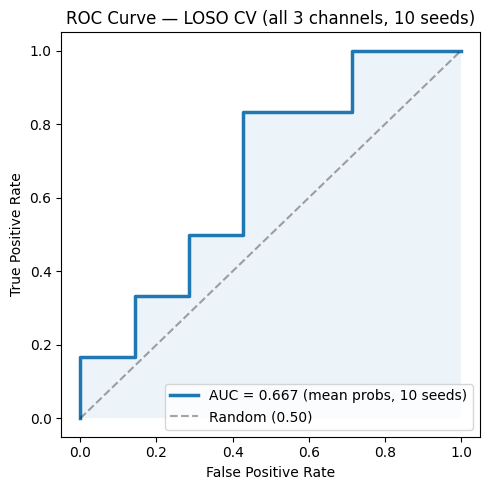

In [13]:
mean_probs_full = res_full['_mean_probs']
fpr, tpr, _ = roc_curve(y_binary, mean_probs_full)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2.5, label=f'AUC = {res_full["ROC-AUC"]:.3f} (mean probs, {N_SEEDS} seeds)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.35, label='Random (0.50)')
ax.fill_between(fpr, tpr, alpha=0.08)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — LOSO CV (all 3 channels, {N_SEEDS} seeds)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 6. Grad-CAM Interpretability

Grad-CAM (Selvaraju et al., 2017) asks: *which time steps in the input most influenced the prediction?*

**How it works (1D adaptation):**
1. Run a forward pass and record the conv2 feature map: shape `(54, 64)` — 54 time steps, 64 filters.
2. Compute the gradient of the predicted probability w.r.t. that feature map.
3. Average the gradient across the time axis to get an importance weight per filter: shape `(64,)`.
4. Weight each filter's activation map by its importance and sum: shape `(54,)`.
5. Apply ReLU (keep only positive activations — those that push the prediction toward the positive class).
6. Resample from 54 → 60 steps to align with the original input window `[−60, ..., −1]`.

**Limitations:** We train the final model on all sessions (no held-out test set), which means  
the attributions are computed from a model that has seen all the data. The Grad-CAM patterns  
reflect what the model has *learned*, not necessarily what will generalise.  
Interpret as hypothesis generation, not confirmation.

Training final model on all sessions (for Grad-CAM)...
Epoch 1/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4769 - loss: 0.7362  
Epoch 2/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8462 - loss: 0.4790
Epoch 3/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8923 - loss: 0.3719
Epoch 4/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9385 - loss: 0.3130
Epoch 5/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9538 - loss: 0.2664
Epoch 6/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9692 - loss: 0.2302
Epoch 7/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9692 - loss: 0.2041
Epoch 8/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9846 - loss: 0.1928
Epoch 9/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 0.1622
Epoch 10/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9846 - loss: 0.1520
Epoch 11/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9538 - loss: 0.1448
Epoch 12/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s

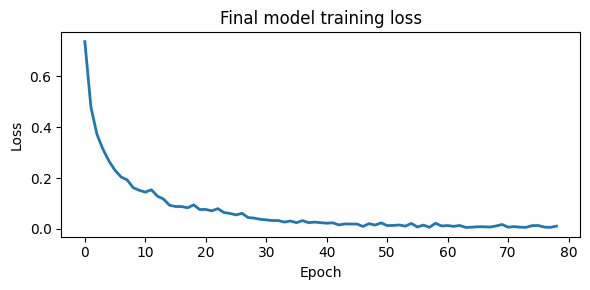

In [14]:
print('Training final model on all sessions (for Grad-CAM)...')
X_all_aug, y_all_aug, pid_all_aug = augment_set(X_norm, y_binary, pid_onehot)

final_model = build_cnn()
history = final_model.fit(
    [X_all_aug, pid_all_aug], y_all_aug,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='loss', patience=ES_PATIENCE, restore_best_weights=True
    )],
    verbose=1,
)

# Plot training loss
plt.figure(figsize=(6, 3))
plt.plot(history.history['loss'], lw=2)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Final model training loss')
plt.tight_layout(); plt.show()

In [15]:
def grad_cam_1d(
    model: keras.Model,
    x_temporal: np.ndarray,   # (60, 3)
    x_pid: np.ndarray,        # (N_PARTICIPANTS,)
    layer_name: str = 'conv2',
) -> np.ndarray:
    """
    Compute Grad-CAM attribution heatmap for one session.

    conv2 output has 54 time steps (60 − 5 + 1 − 3 + 1).
    Output is resampled to 60 steps for alignment with the input window.
    Returns normalised heatmap in [0, 1], shape (60,).
    """
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output],
    )
    x_t = tf.cast(x_temporal[np.newaxis], tf.float32)  # (1, 60, 3)
    x_p = tf.cast(x_pid[np.newaxis],      tf.float32)  # (1, N_PARTICIPANTS)

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model([x_t, x_p])
        score = pred[:, 0]   # P(mood improves)

    grads       = tape.gradient(score, conv_out)              # (1, 54, 64)
    pooled_grad = tf.reduce_mean(grads, axis=(0, 1))          # (64,)
    cam         = tf.reduce_mean(conv_out[0] * pooled_grad, axis=-1)  # (54,)
    cam         = tf.nn.relu(cam)
    cam         = cam / (tf.reduce_max(cam) + 1e-8)           # normalise to [0, 1]

    # Resample 54 → 60 steps
    cam_np = cam.numpy()
    cam_60 = np.interp(
        np.linspace(0, 1, N_STEPS),
        np.linspace(0, 1, len(cam_np)),
        cam_np,
    )
    return cam_60.astype(np.float32)

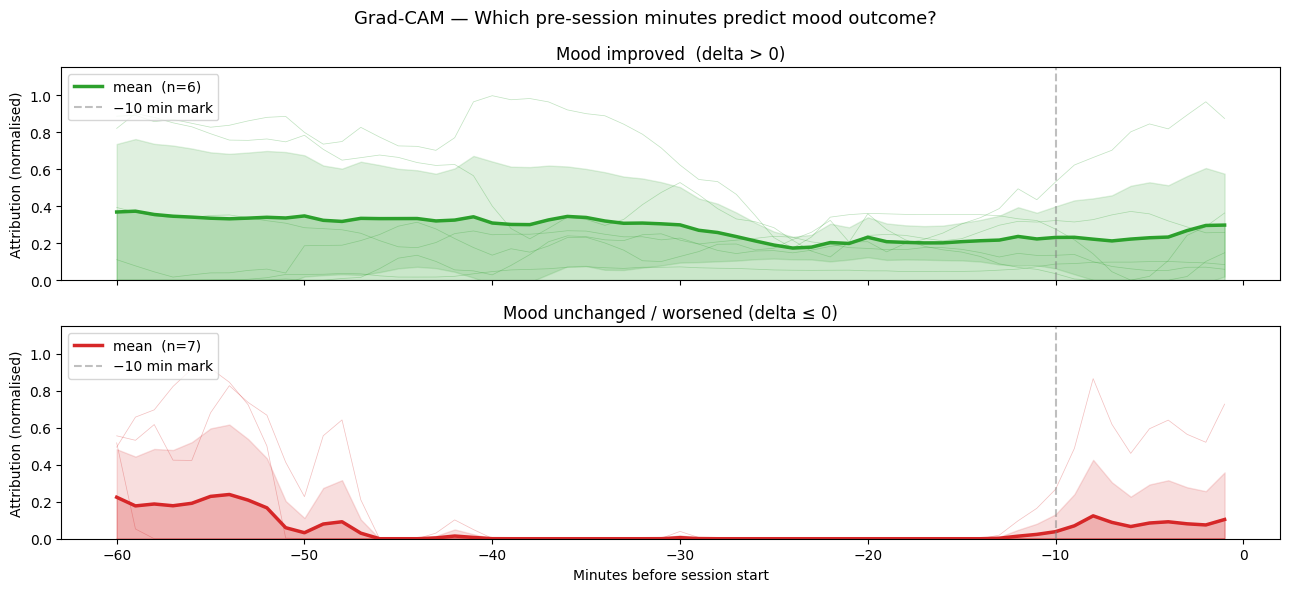


Note: heatmap peaks near t=0 suggest the model weights the most recent state most heavily.
Peaks at t≈−30 to −10 would suggest mid-window physiological patterns matter more.


In [16]:
# Compute Grad-CAM for every session; group by outcome class
heatmaps = {'improved': [], 'not_improved': []}
for i in range(len(meta)):
    cam = grad_cam_1d(final_model, X_norm[i], pid_onehot[i])
    key = 'improved' if y_binary[i] == 1 else 'not_improved'
    heatmaps[key].append(cam)

x_minutes = np.arange(-N_STEPS, 0)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
configs = [
    ('improved',     'Mood improved  (delta > 0)',   '#2ca02c'),
    ('not_improved', 'Mood unchanged / worsened (delta ≤ 0)', '#d62728'),
]
for ax, (key, title, color) in zip(axes, configs):
    cams = heatmaps[key]
    if not cams:
        ax.text(0.5, 0.5, 'No sessions in this class', transform=ax.transAxes, ha='center')
        ax.set_title(title); continue
    mean_cam = np.mean(cams, axis=0)
    std_cam  = np.std(cams,  axis=0)
    ax.fill_between(x_minutes, mean_cam - std_cam, mean_cam + std_cam, alpha=0.15, color=color)
    ax.fill_between(x_minutes, 0, mean_cam, alpha=0.25, color=color)
    ax.plot(x_minutes, mean_cam, color=color, lw=2.5, label=f'mean  (n={len(cams)})')
    for cam in cams:
        ax.plot(x_minutes, cam, color=color, lw=0.5, alpha=0.3)
    ax.axvline(-10, ls='--', color='grey', alpha=0.5, label='−10 min mark')
    ax.set_ylabel('Attribution (normalised)')
    ax.set_title(title)
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Minutes before session start')
plt.suptitle('Grad-CAM — Which pre-session minutes predict mood outcome?', fontsize=13)
plt.tight_layout()
plt.show()

# Also: mean heatmap per participant for both classes
print('\nNote: heatmap peaks near t=0 suggest the model weights the most recent state most heavily.')
print('Peaks at t≈−30 to −10 would suggest mid-window physiological patterns matter more.')

---
## 7. Ablation Study — Channel Contribution

Re-run LOSO with only a subset of input channels to understand which signal carries most  
predictive information:

| Variant | Channels | Hypothesis |
|---------|----------|------------|
| Stress only | `[stress]` | Stress trajectory is the dominant predictor |
| HR only | `[heart_rate]` | HR is the dominant predictor (denser signal) |
| All 3 channels | `[stress, body_battery, heart_rate]` | Multi-channel fusion improves over any single channel |

> Body battery is intentionally not tested as a standalone — it changes so slowly that  
> a 60-minute window contains very little variance.

In [17]:
ABLATION_CONFIGS = {
    'stress only'    : [0],
    'HR only'        : [2],
    'all 3 channels' : [0, 1, 2],
}

ablation_rows = []
for name, ch_idx in ABLATION_CONFIGS.items():
    ch_names = [CHANNELS[i] for i in ch_idx]
    print(f'\n── Ablation: {name}  ({ch_names}) ──')
    row = run_loso_multiseed(X_norm, y_binary, pid_onehot,
                             channel_indices=ch_idx, label=name)
    ablation_rows.append(row)
    print(f'   AUC={row["ROC-AUC"]:.3f}  ±{row["AUC std  (per-seed)"]:.3f}   '
          f'BalAcc={row["Balanced Accuracy"]:.3f}')

print('\nDone.')


── Ablation: stress only  (['stress']) ──
  seed 42  AUC=0.571
  seed 43  AUC=0.548
  seed 44  AUC=0.667
  seed 45  AUC=0.476
  seed 46  AUC=0.643
  seed 47  AUC=0.524
  seed 48  AUC=0.643
  seed 49  AUC=0.738
  seed 50  AUC=0.500
  seed 51  AUC=0.571
   AUC=0.548  ±0.078   BalAcc=0.619

── Ablation: HR only  (['heart_rate']) ──
  seed 42  AUC=0.476
  seed 43  AUC=0.524
  seed 44  AUC=0.452
  seed 45  AUC=0.571
  seed 46  AUC=0.500
  seed 47  AUC=0.524
  seed 48  AUC=0.595
  seed 49  AUC=0.405
  seed 50  AUC=0.452
  seed 51  AUC=0.381
   AUC=0.500  ±0.065   BalAcc=0.464

── Ablation: all 3 channels  (['stress', 'body_battery', 'heart_rate']) ──
  seed 42  AUC=0.619
  seed 43  AUC=0.643
  seed 44  AUC=0.595
  seed 45  AUC=0.619
  seed 46  AUC=0.619
  seed 47  AUC=0.595
  seed 48  AUC=0.643
  seed 49  AUC=0.643
  seed 50  AUC=0.643
  seed 51  AUC=0.643
   AUC=0.619  ±0.019   BalAcc=0.619

Done.


Ablation results:


,ROC-AUC,AUC std (per-seed),Balanced Accuracy,Precision,Recall
label,,,,,
stress only,0.55,0.08,0.62,0.57,0.67
HR only,0.50,0.07,0.46,0.43,0.50
all 3 channels,0.62,0.02,0.62,0.57,0.67


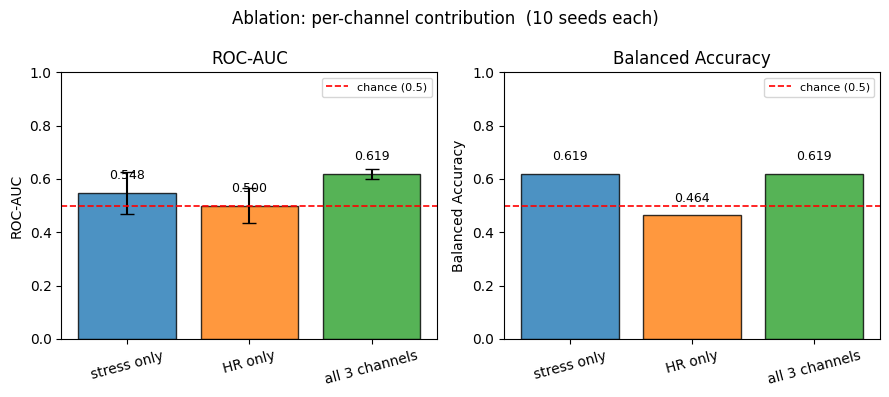

In [18]:
abl_df = pd.DataFrame(ablation_rows).set_index('label')

display_cols = ['ROC-AUC', 'AUC std  (per-seed)', 'Balanced Accuracy', 'Precision', 'Recall']
print('Ablation results:')
display(abl_df[display_cols])

# Bar chart with error bars
metrics_to_plot = ['ROC-AUC', 'Balanced Accuracy']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(9, 4), sharey=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, metric in zip(axes, metrics_to_plot):
    yerr = abl_df['AUC std  (per-seed)'] if metric == 'ROC-AUC' else None
    bars = ax.bar(abl_df.index, abl_df[metric], color=colors, alpha=0.8,
                  edgecolor='k', yerr=yerr, capsize=5)
    ax.axhline(0.5, color='red', ls='--', lw=1.2, label='chance (0.5)')
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, abl_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.04, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Ablation: per-channel contribution  ({N_SEEDS} seeds each)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Summary & Caveats

### What this notebook produces
- A trained 1D-CNN that predicts mood improvement from the 60-minute physiological pre-session window
- LOSO cross-validated AUC, precision, recall, balanced accuracy
- Grad-CAM attribution heatmaps showing *which minutes* in the pre-session window the model focuses on
- An ablation table showing the contribution of each physiological channel

### Honest caveats

| Issue | Impact |
|-------|--------|
| N ≈ 17 sessions | AUC variance ~±0.15; a single session can flip results |
| Only 2 participants | Model may learn participant-specific artefacts rather than general patterns |
| Stress forward-fill | Some sessions may have up to 4 minutes of extrapolated stress |
| Grad-CAM trained on all data | Attributions are in-sample; do not generalise claims |
| No held-out test set | All LOSO results are themselves estimates with high CI |

### Next steps
1. **Add more participants** as data becomes available — each new participant significantly reduces variance
2. **Per-playlist-type analysis** — does the model perform better for calm vs energy sessions?
3. **Compare to logistic regression baseline** on handcrafted features (pre-session mean stress, slope) — if LR matches the CNN, the temporal structure isn't adding value
4. **Per-participant models** — with enough sessions (≥20 per participant), fine-tune the shared model for each person